In [101]:
import numpy as np
import matplotlib.pyplot as plt

# Функция для вычисления определителя матрицы
def determinant_matrix(mat):
    n = len(mat) # размерность квадратной матрицы
    if n == 1:
        return mat[0][0]
    if n == 2:
        return mat[0][0] * mat[1][1] - mat[0][1] * mat[1][0]
    
    det = 0
    for j in range(n): # перебираем элементы первой строки
        sub_mat = np.delete(np.delete(mat, 0, axis=0), j, axis=1) # минор (подматрица, которая остаётся после удаления i-й строки и j-го столбца)
        det += ((-1) ** j) * mat[0][j] * determinant_matrix(sub_mat) # ищем определитель: (-1)^j * c_0j * det(sub_mat)

    return det

# Функция для вычисления обратной матрицы
def inverse_matrix(mat):
    n = len(mat)
    det = determinant_matrix(mat)

    if det == 0:
        raise ValueError("Матрица вырожденная, обратной матрицы не существует.") # генерация исключения
    
    # Создаём матрицу алгебраических дополнений
    adjugate = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            sub_mat = np.delete(np.delete(mat, i, axis=0), j, axis=1) 
            adjugate[j][i] = ((-1) ** (i + j)) * determinant_matrix(sub_mat)
    
    return adjugate / det

# Ввод матрицы платежей
C = np.array([[12, 9, 18], 
              [15, 22, 5], 
              [16, 3, 12]])

# Метод обратной матрицы (аналитическое решение)
# Вычисляем определитель и обратную матрицу.
# Используем единичный вектор u = [1, 1, 1].
# Находим оптимальные стратегии и цену игры.
C_inv = inverse_matrix(C) #обратная матрица
# Аналитический метод (обратная матрица)
# Вычисление оптимальных стратегий
u = np.ones(len(C))
v = 1 / np.dot(np.dot(u, C_inv), u.T) 
x_opt = np.dot(u, C_inv) * v
y_opt = np.dot(C_inv, u.T) * v

k   Выбор A    Выбор B    x1    x2    x3    y1    y2    y3    1/k*u_up[k]  1/k*u_down[k] epsilon
------------------------------------------------------------------------------------------
1   x_2          y_1      12    15    16    15    22    5     16.0         5.0          11.0 
------------------------------------------------------------------------------------------
2   x_3          y_3      30    20    28    31    25    17    15.0         8.5          6.5  
------------------------------------------------------------------------------------------
3   x_1          y_3      48    25    40    43    34    35    16.0         11.333       3.667
------------------------------------------------------------------------------------------
4   x_1          y_2      57    47    43    55    43    53    14.25        10.75        2.917
------------------------------------------------------------------------------------------
5   x_1          y_2      66    69    46    67    52    71    13.8      

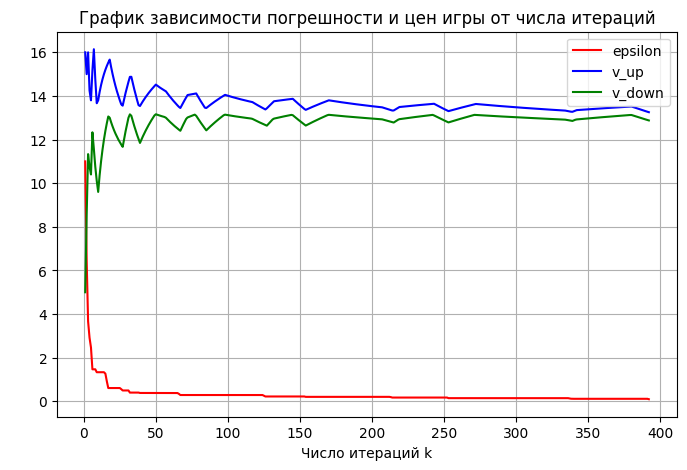

In [102]:
# Метод Брауна–Робинсон (итерационный алгоритм)
def braun_robinson(C, epsilon):
    n, m = C.shape # число стратегий игроков

    A = np.zeros(n) # массив из n нулей
    B = np.zeros(m) # массив из m нулей

    x_count = np.zeros(n)
    y_count = np.zeros(m)

    I_A = np.random.randint(0, 2)
    I_B = np.random.randint(0, 2)
    
    A = C[:,I_B] # рандомный столбец C
    B = C[I_A,:] # рандомная строка C
    
    x_count[0] += 1
    y_count[0] += 1
    
    v_up_arr = []
    v_down_arr= []
    eps_arr = []
    k_arr = []
    eps = 1000
    
    k = 0

    headers = ["k", "Выбор A", "Выбор B", "x1", "x2", "x3", "y1", "y2", "y3", "1/k*u_up[k]", "1/k*u_down[k]", "epsilon"]
    print(f"{headers[0]:<3} {headers[1]:<10} {headers[2]:<10} {headers[3]:<5} {headers[4]:<5} {headers[5]:<5} {headers[6]:<5} {headers[7]:<5} {headers[8]:<5} {headers[9]:<12} {headers[10]:<12} {headers[11]:<5}")
    print("-" * 90)  
    
    while eps >= epsilon:
        k+=1 # номер итерации
        k_arr.append(k)
        x_count[I_A] += 1 # увеличение числа выборов одной из стратегий игрока А
        y_count[I_B] += 1 # увеличение числа выборов одной из стратегий игрока B
        v_up   = max(A)/k # верхняя цена игры
        v_down = min(B)/k # нижняя цена игры
        v_up_arr.append(v_up) # массив верхних цен
        v_down_arr.append(v_down) # массив нижних цен

        eps = min(v_up_arr) - max(v_down_arr) # погрешность 
        eps_arr.append(eps)
        print(f"{k:<3} x_{I_A+1:<10} y_{I_B+1:<6} {A[0]:<5} {A[1]:<5} {A[2]:<5} {B[0]:<5} {B[1]:<5} {B[2]:<5} {round(v_up,3):<12} {round(v_down,3):<12} {round(eps,3):<5}")
        print("-" * 90) 

        if A[I_A] < A[np.argmax(A)]:
            I_A = np.argmax(A)
        if B[I_B] > B[np.argmin(B)]:
            I_B = np.argmin(B)

        # суммирование выигрышей
        A = A+C[:,I_B]
        B = B+C[I_A,:]

    x_opt_br = x_count/k
    y_opt_br = y_count/k
    print("Метод обратной матрицы\n") 
    print(f"Цена игры (v): {round(v,3)}") 
    print(f"Оптимальная стратегия игрока A: {np.round(x_opt,3)}")
    print(f"Оптимальная стратегия игрока B: {np.round(y_opt,3)}")
    print(f"\n")

    print("Алгоритм Брауна-Робинсон\n")
    print(f"Оптимальная стратегия игрока A: {np.round(x_opt_br,3)}\n")
    print(f"Оптимальная стратегия игрока B: {np.round(y_opt_br,3)}\n")
    print(f"Погрешность: eps[{k}] = {round(eps,3)}")
    print(f"Верхняя цена игры: v_up = {round(min(v_up_arr),3)}")
    print(f"Нижняя цена игры: v_down = {round(max(v_down_arr),3)}")
    return k_arr, eps_arr, v_up_arr, v_down_arr

# Функция для построения графика функции
def plot_function(k_array, eps_array, v_up_array, v_down_array):
        plt.figure(figsize=(8, 5))
        
        plt.plot(k_array, eps_array, 'r-', label="epsilon")
        plt.plot(k_array, v_up_array, 'b-', label="v_up")
        plt.plot(k_array, v_down_array, 'g-', label="v_down")

        plt.xlabel("Число итераций k")
        plt.ylabel(" ")
        plt.legend()
        plt.grid(True)
        plt.title("График зависимости погрешности и цен игры от числа итераций")
        plt.show()

# Основная программа
k_arr = []
v_up_arr = []
v_down_arr= []
eps_arr = []
k_arr, eps_arr, v_up_arr, v_down_arr = braun_robinson(C,epsilon=0.1)
plot_function(k_arr, eps_arr, v_up_arr, v_down_arr)
